> <div style="padding:15px 10px 1px 10px; border-radius:10px;"><h3> Early Depression Detection in Students </h3></div>


> <p style="padding:10px;"> Importing Libraries </p>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import PMeasures as Pm
print("done")

done


> <p style="padding:10px;"> Fetching data from dataSet </p>

In [5]:
df = pd.read_csv("student_depression_dataset.csv")

df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


> <p style="padding:10px">Preprocessing</p>

In [6]:
import pickle
df = df.drop(["id", "Work Pressure",'Profession','Job Satisfaction'], axis=1)

l1 = ['Saanvi','M.Tech','Bhavna',"'Less Delhi'",'City','3.0',"'Less than 5 Kalyan'",'Mira','Harsha','Vaanya','Gaurav','Harsh','Reyansh','Kibara','Rashi','ME','M.Com','Nalyan','Mihir','Nalini','Nandini',]

df = df.drop(df[df['City'].isin(l1) ].index)

bin_cols = ['Gender','Have you ever had suicidal thoughts ?','Family History of Mental Illness'] # collection of all binary features

df = pd.get_dummies(df, drop_first=True) # One-hot encoding
# encoding non binary values to binary values 



> <p style="padding : 10px;">Performing Actual Training (KNN), Train Test Split and measuring Performance</p> 

In [11]:
  
X = df.drop("Depression", axis=1)
y = df["Depression"]

def evaluate_model(test_size):

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=0)

    # Scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # finding best value for K
    k_values = range(1, 21)
    accuracies = []

    for k in k_values:
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracies.append(accuracy_score(y_test, y_pred))

    best_k = k_values[np.argmax(accuracies)]

    print("Best K:", best_k,"\n")

    # Train model with best K
    model = KNeighborsClassifier(n_neighbors=best_k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    TN,FP,FN,TP = cm.ravel()

    # Scores
    accuracy = Pm.accuracy(TN,FP,FN,TP)
    precision = Pm.precision(TN,FP,FN,TP)
    recall = Pm.recall(TN,FP,FN,TP)
    specificity = Pm.specificity(TN,FP,FN,TP)
    f1 =Pm.fmeasure(TN,FP,FN,TP)
    g_mean = Pm.gmean(TN,FP,FN,TP)
    g_measure = Pm.gmeasure(TN,FP,FN,TP)

    # Print results
    print("Accuracy\t\tPrecision\t\tRecall\t\t\tSpecificity\t\tf1Score\t\t\tG Mean\t\t\tG Measure")
    print(f"{accuracy}\t{precision}\t{recall}\t{specificity}\t{f1}\t{g_mean}\t{g_measure}\t\n")
    print(cm)
    return k_values, accuracies, model

# Runnin for different splits
k1, acc1, model = evaluate_model(0.3)  # 70-30
k2, acc2,model2 = evaluate_model(0.2)  # 80-20


Best K: 16 

Accuracy		Precision		Recall			Specificity		f1Score			G Mean			G Measure
0.7195982303001315	0.7403057419835943	0.8066219784684135	0.2279576164090601	0.7720423835909399	0.4288072102411756	0.7727527950582475	

[[2047 1393]
 [ 952 3971]]
Best K: 18 

Accuracy		Precision		Recall			Specificity		f1Score			G Mean			G Measure
0.7250717360114778	0.7359934408308281	0.8260736196319018	0.22156380979910395	0.778436190200896	0.42781773962772984	0.779733778729933	

[[1350  966]
 [ 567 2693]]


> <p style="padding : 10px;">Ploting Graph for Best value of K</p> 

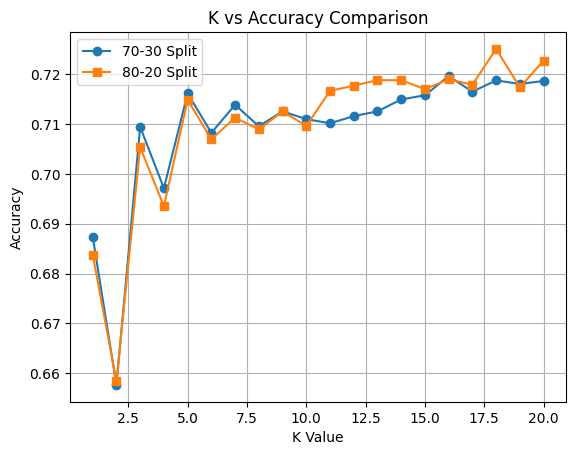

In [12]:
plt.figure()
plt.plot(k1, acc1, marker='o', label="70-30 Split")
plt.plot(k2, acc2, marker='s', label="80-20 Split")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy Comparison")
plt.legend()
plt.grid()

plt.show()